# Assignment 1: Extraction of Discriminative Features for Anomaly Detection on Acoustic Data

- **Course**: [CIVIL-426 - Machine Learning for Predictive Maintenance](https://edu.epfl.ch/coursebook/en/machine-learning-for-predictive-maintenance-applications-CIVIL-426)
- **Start Date**: 2025.09.19 at 10h15
- **Due Date**: 2025.10.13 at 23h59
- **Student 0**:
    - First and Last name: Arthur Van den Broeck
    - SCIPER: 361121
- **Student 1**:
    - First and Last name: `FILL HERE`
    - SCIPER: `FILL HERE`

## Introduction

This notebook is divided in 3 parts:
- [Part 0](#part-0-demonstration): Basic Anomaly Detection on a toy dataset

This part shows how to extract discriminative features for anomaly detection on a toy 
dataset. This part of the notebook runs without any issues on a properly configured 
machine. You are **not** expected to fill anything in this part.

- [Part 1](#part-1-feature-based-anomaly-detection): Feature-based Anomaly Detection

This part contains the detailed questions and assignments of the graded exercise. You
are expected to fill this part with your own code and your own answers to the questions.

- [Part 2](#part-2-classification-based-anomaly-detection): Classification-based Anomaly Detection

This part contains the detailed questions and assignments of the graded exercise. You
are expected to fill this part with your own code and your own answers to the questions.

⚠️ The deadline to hand-in a PDF report along this completed notebook is 
**October 13th, 2025 at 23h59**. No submissions will be accepted past this deadline. ⚠️

---

## Part 0: Demonstration

### 0. Introduction

The **goals** of this exercise are:

* Extracting statistical features of acoustic signals to discriminate between normal and abnormal samples
* Defining a threshold-based anomaly detection rule based on normal samples only

The **requirements** are:
* Your method can use a single feature or a combination of features
* You must include visualization in a meaningful way
* Your method must be developed based on the **TRAIN set** only

This part contains an example on a toy dataset.

1. **Train**: training set containing only healthy (normal) samples
2. **Test**: test set containing both normal and abnormal samples.

### 1. Notebook Configuration

In [25]:
%matplotlib inline

import os
import zipfile

import gdown
import librosa
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import numpy as np
from numpy.fft import fft
import pandas as pd
import seaborn as sns
import scipy.stats as scist
from sklearn import metrics
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm.notebook import tqdm


### 2. Load the Dataset 

In [26]:
# Download the dataset
os.makedirs("part_0", exist_ok=True)
if not os.path.isfile("part_0/toy_data.npz"):
    gdown.download(id="1PhWTvX7KbXpJSpCt2U8d2AN6qv18asQU", output="./part_0/toy_data.npz")

# Load the dataset from your disk (you must have downloaded the file)
data = np.load("part_0/toy_data.npz")

# Extract the training and testing set
train_set = data["train"]
test_set = data["test"]

train_set_size = train_set.shape[0]
train_set_timesteps = train_set.shape[1]
test_set_size = test_set.shape[0]
test_set_timesteps = test_set.shape[1]


In [27]:
# About the train dataset
print(
    f"The TRAINING set contains {train_set_size} recordings. "
    f"Each recording contains {train_set_timesteps} samples."
)

# About the test dataset
print(
    f"The TESTING set contains {test_set_size} recordings. "
    f"Each recording contains {test_set_timesteps} samples."
)


The TRAINING set contains 500 recordings. Each recording contains 1000 samples.
The TESTING set contains 200 recordings. Each recording contains 1000 samples.


### 3. Visual Signals

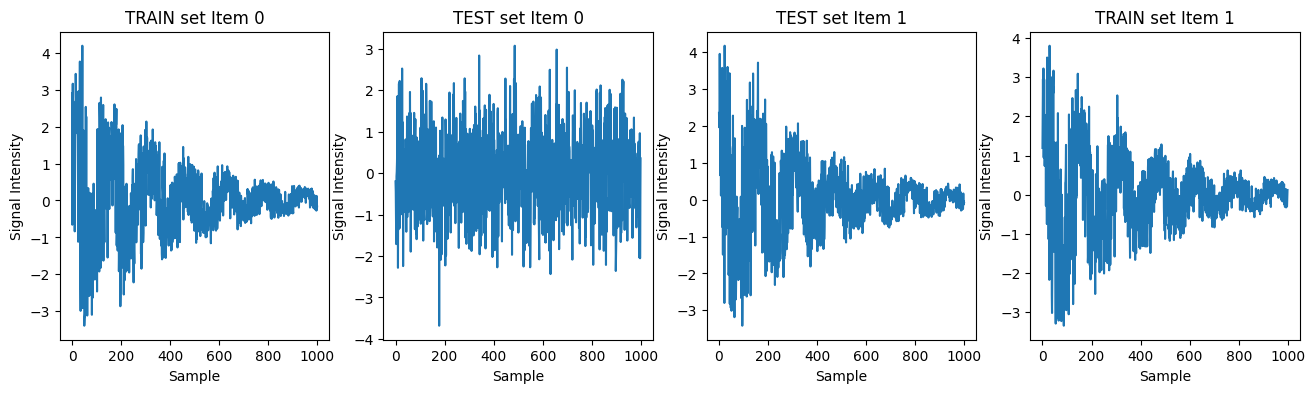

In [28]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].plot(train_set[0])
ax[0].set_title("TRAIN set Item 0")
ax[1].plot(test_set[0])
ax[1].set_title("TEST set Item 0")
ax[2].plot(test_set[1])
ax[2].set_title("TEST set Item 1")
ax[3].plot(train_set[1])
ax[3].set_title("TRAIN set Item 1")

for i in range(4):
    ax[i].set_xlabel("Sample")
    ax[i].set_ylabel("Signal Intensity")


### 4. Compute Absolute Values

In [29]:
train_set_abs = np.abs(train_set)
test_set_abs = np.abs(test_set)


### 5. Compute Min, Max, Centered Moments and Centralized Moments

In [30]:
# Compute moments 1 to 4 on the training set and assign them in a Pandas dataframe
train_moments = pd.DataFrame(
    {
        "MaxAbs": np.amax(train_set_abs, axis=1),
        "Mean": np.mean(train_set, axis=1),
        "Variance": scist.moment(train_set, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(train_set, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            train_set, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "train",
    }
)

# Compute moments 1 to 4 on the testing set and assign them in a Pandas dataframe
test_moments = pd.DataFrame(
    {
        "MaxAbs": np.amax(test_set_abs, axis=1),
        "Mean": np.mean(test_set, axis=1),
        "Variance": scist.moment(test_set, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(test_set, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            test_set, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "test",
    }
)


### 6. Fourier Transform and Spectrum Skewness

In [31]:
# Remove DC compoent and calculate FFT
train_spectrum = 2.0 / train_set_size * np.abs(fft(train_set, axis=1, norm=None))
test_spectrum = 2.0 / test_set_size * np.abs(fft(test_set, axis=1, norm=None))

# Compute Skewness of the Sprectrum excluding the 0 [Hz] component
train_moments["SpSkew"] = scist.skew(
    train_spectrum[:, 1:], axis=1, bias=True, nan_policy="propagate"
)
test_moments["SpSkew"] = scist.skew(
    test_spectrum[:, 1:], axis=1, bias=True, nan_policy="propagate"
)


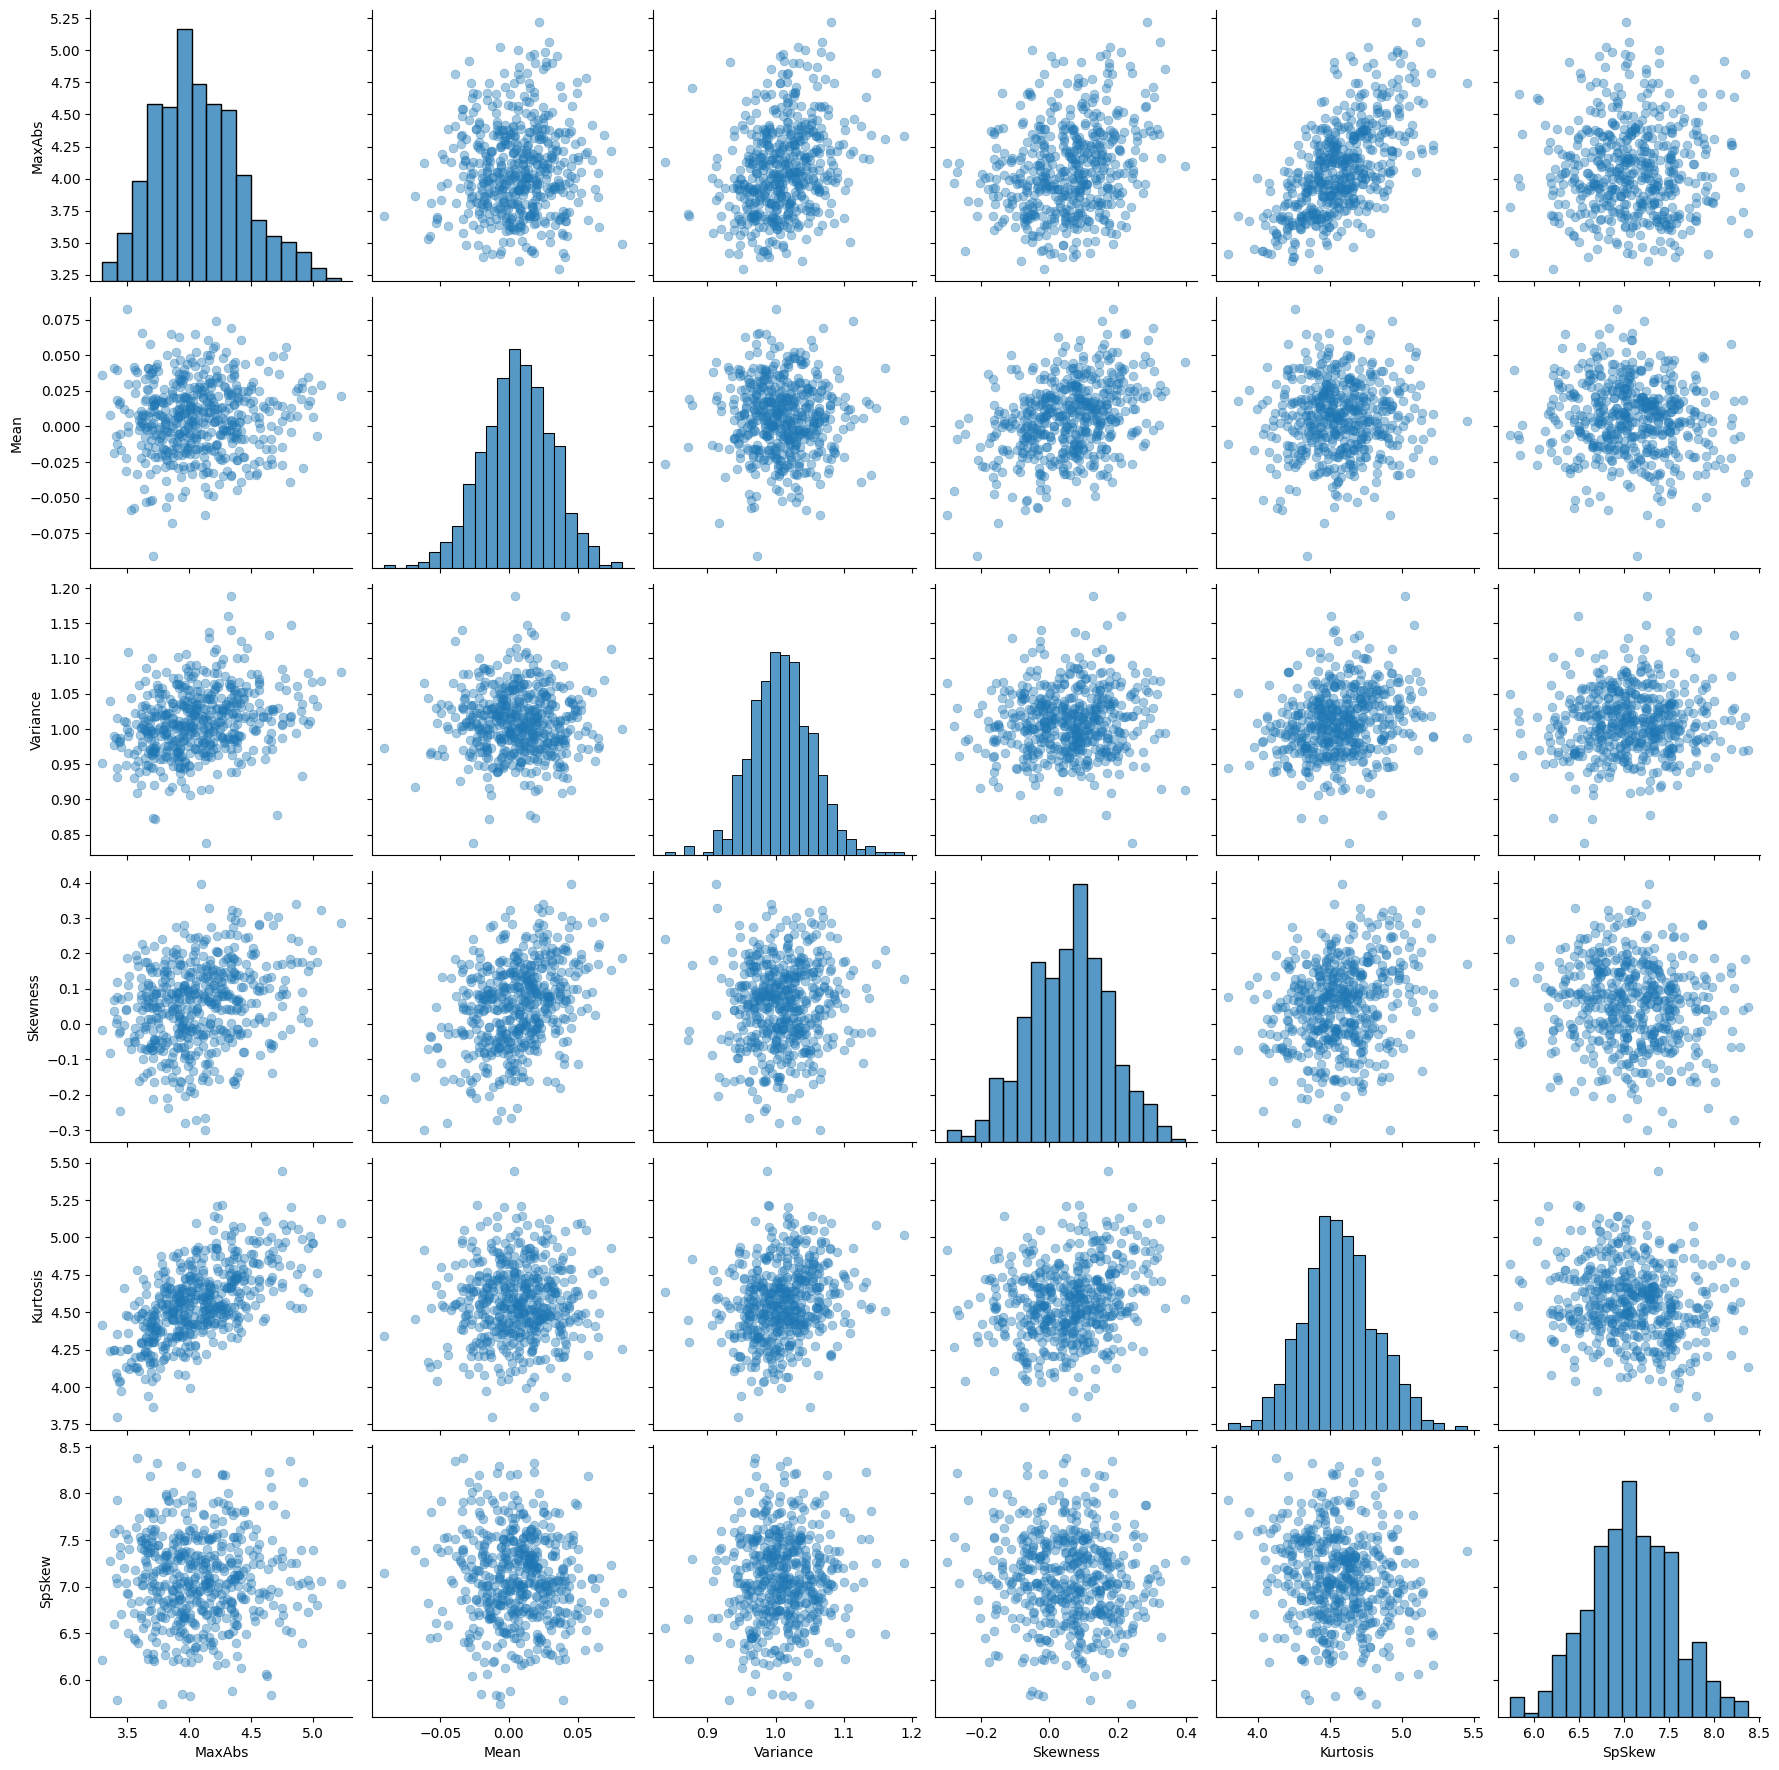

In [32]:
# If working on macOS, you want to specify that the diagonal plot should be histograms to avoid errors when plotting
# Otherwise you can leave the lines commented
sns.pairplot(
    train_moments,
    vars=[c for c in train_moments.columns if c != "type"],
    height=3,
    plot_kws={"alpha": 0.4, "s": 40, "edgecolor": None},
)
#            diag_kind = 'hist',
#           diag_kws = {'alpha': 0.4, 'log':True, 'density':True}
# )


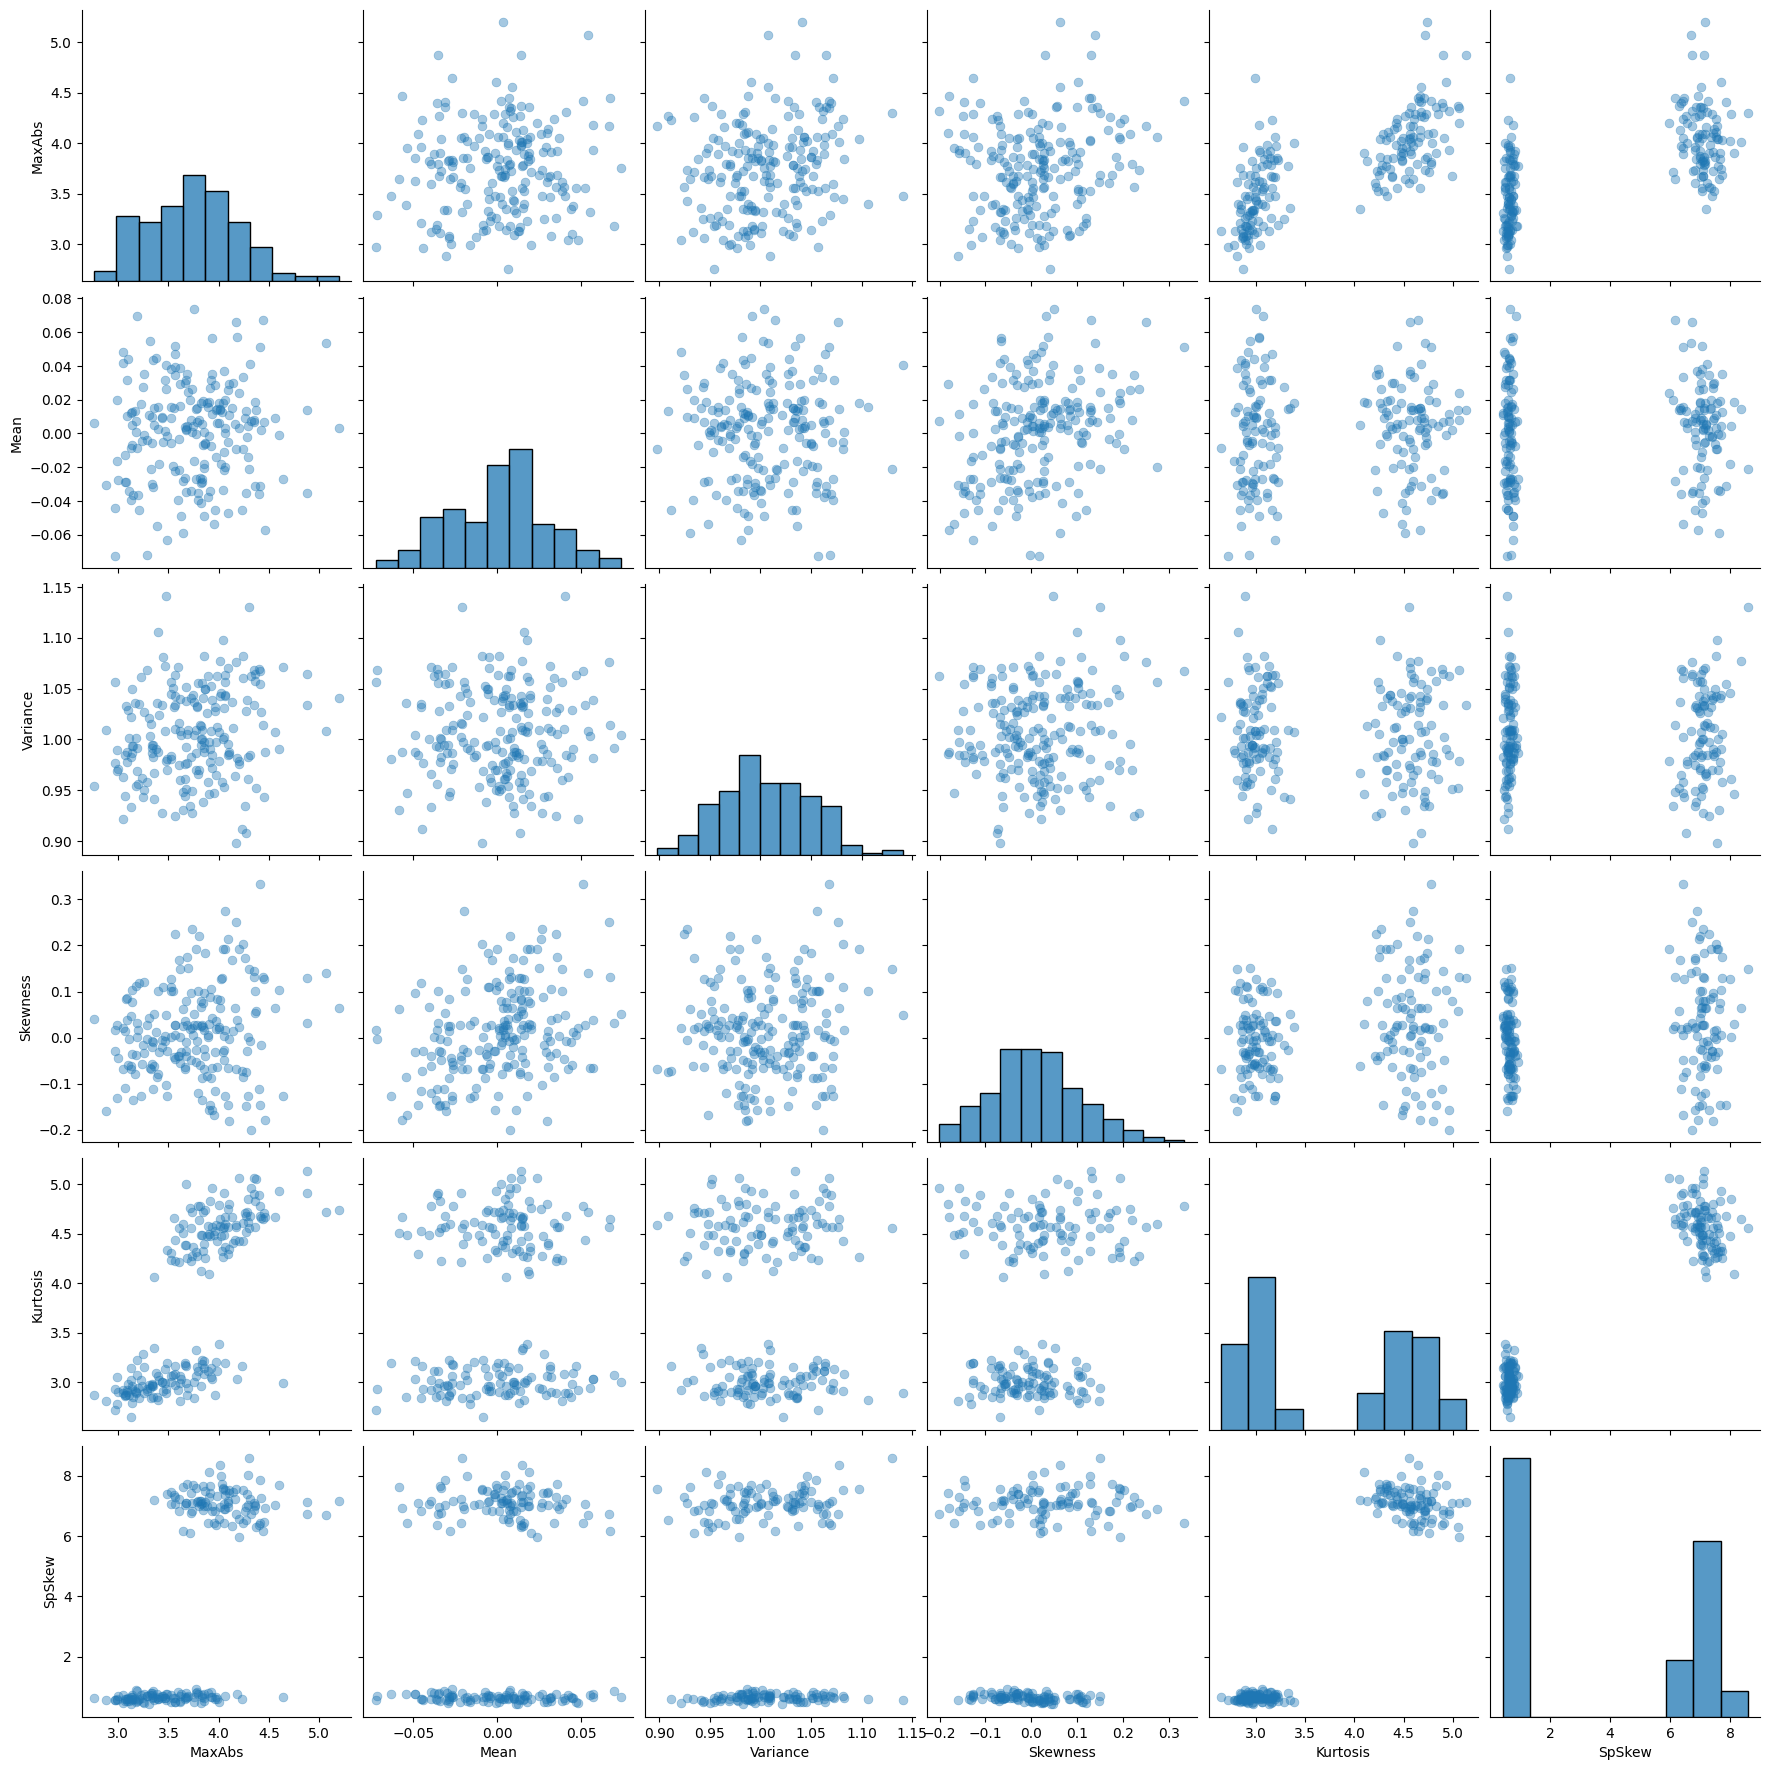

In [33]:
# If working on macOS, you want to specify that the diagonal plot should be histograms to avoid errors when plotting
# Otherwise you can leave the lines commented
sns.pairplot(
    test_moments,
    vars=[c for c in test_moments.columns if c != "type"],
    height=3,
    plot_kws={"alpha": 0.4, "s": 40, "edgecolor": None},
    #diag_kind = 'hist',
    #diag_kws = {'alpha': 0.4, 'log':True, 'density':True}
)
# ,
            
           


### 7. Defining thresholds based on normal data percentiles

Here, we define an anomaly detection rule based on thresholds, corresponding to the [0.5, 99.5] percentiles of the feature distributions of normal samples. In other words, a feature higher than 99.5% or lower than 0.5% of the normal features is considered an anomaly. Using only normal samples to base the decision is motivated by the facts that:

1. Few anomalies are observed
2. We cannot observe every possible anomaly

Anomalies are outliers with respect to the normal data distribution.

Text(0, 0.5, 'Percentile')

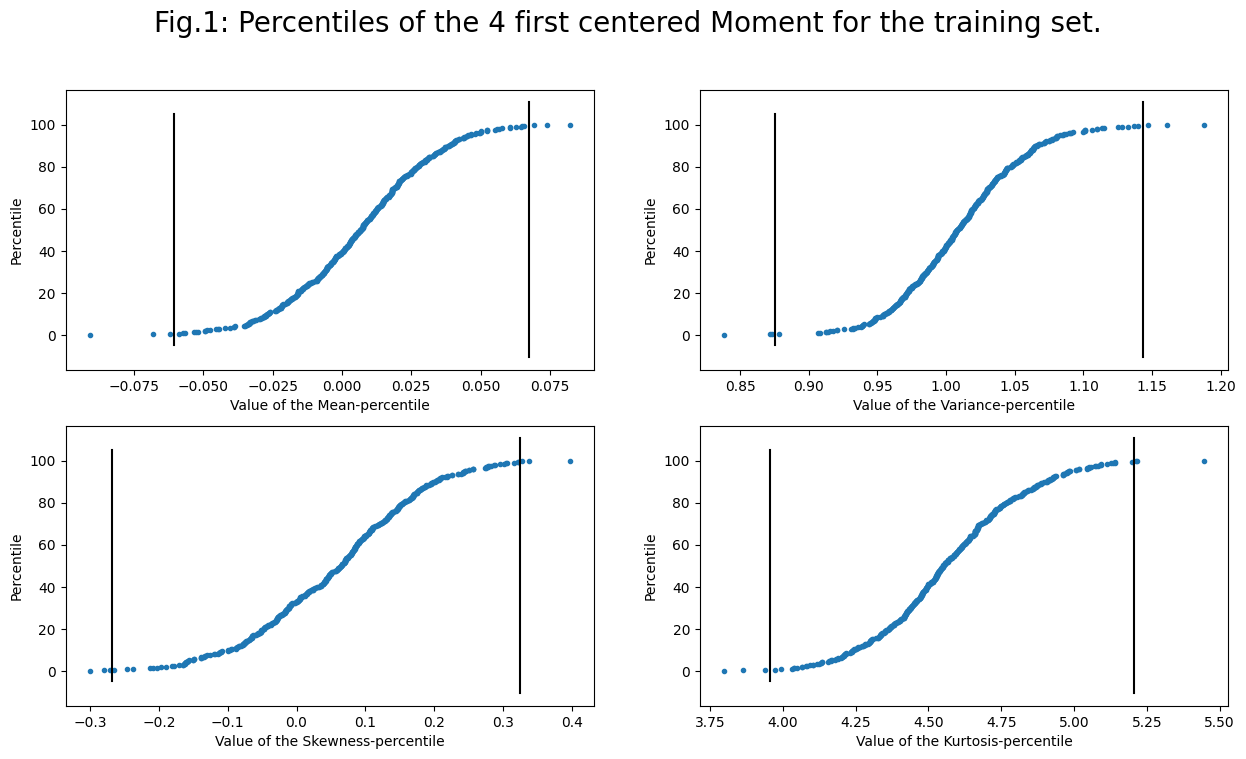

In [34]:
quantiles = [0.5, 99.5]
limit_max_abs = np.percentile(train_moments.loc[:, "MaxAbs"], quantiles) #Calculates the value of the quantile limits in maxabs, .loc extracts the respective column
limit_mean = np.percentile(train_moments.loc[:, "Mean"], quantiles)
limit_variance = np.percentile(train_moments.loc[:, "Variance"], quantiles)
lim_skew = np.percentile(train_moments.loc[:, "Skewness"], quantiles)
limit_kurtosis = np.percentile(train_moments.loc[:, "Kurtosis"], quantiles)
limit_sp_skew = np.percentile(train_moments.loc[:, "SpSkew"], quantiles)

train_percentage = np.linspace(0, 100, train_set_size)  # From 0% to 100% -> creates an array for each entre with same spacing (ex. 400 entries in train_set_size -> spaced by 100/400)

plt.figure(1, figsize=(15, 8))
plt.clf()
plt.suptitle(
    "Fig.1: Percentiles of the 4 first centered Moment for the training set.",
    fontsize=20,
)
plt.subplot(2, 2, 1)
plt.plot(
    np.sort(train_moments.loc[:, "Mean"]), train_percentage, marker=".", linewidth=0
)
plt.plot([limit_mean[0], limit_mean[0]], plt.ylim(), color="k")
plt.plot([limit_mean[1], limit_mean[1]], plt.ylim(), color="k")
plt.xlabel("Value of the Mean-percentile")
plt.ylabel("Percentile")
plt.subplot(2, 2, 2)
plt.plot(
    np.sort(train_moments.loc[:, "Variance"]), train_percentage, marker=".", linewidth=0
)
plt.plot([limit_variance[0], limit_variance[0]], plt.ylim(), color="k")
plt.plot([limit_variance[1], limit_variance[1]], plt.ylim(), color="k")
plt.xlabel("Value of the Variance-percentile")
plt.ylabel("Percentile")
plt.subplot(2, 2, 3)
plt.plot(
    np.sort(train_moments.loc[:, "Skewness"]), train_percentage, marker=".", linewidth=0
)
plt.plot([lim_skew[0], lim_skew[0]], plt.ylim(), color="k")
plt.plot([lim_skew[1], lim_skew[1]], plt.ylim(), color="k")
plt.xlabel("Value of the Skewness-percentile")
plt.ylabel("Percentile")
plt.subplot(2, 2, 4)
plt.plot(
    np.sort(train_moments.loc[:, "Kurtosis"]), train_percentage, marker=".", linewidth=0
)
plt.plot([limit_kurtosis[0], limit_kurtosis[0]], plt.ylim(), color="k")
plt.plot([limit_kurtosis[1], limit_kurtosis[1]], plt.ylim(), color="k")
plt.xlabel("Value of the Kurtosis-percentile")
plt.ylabel("Percentile")


Text(0, 0.5, 'Percentile')

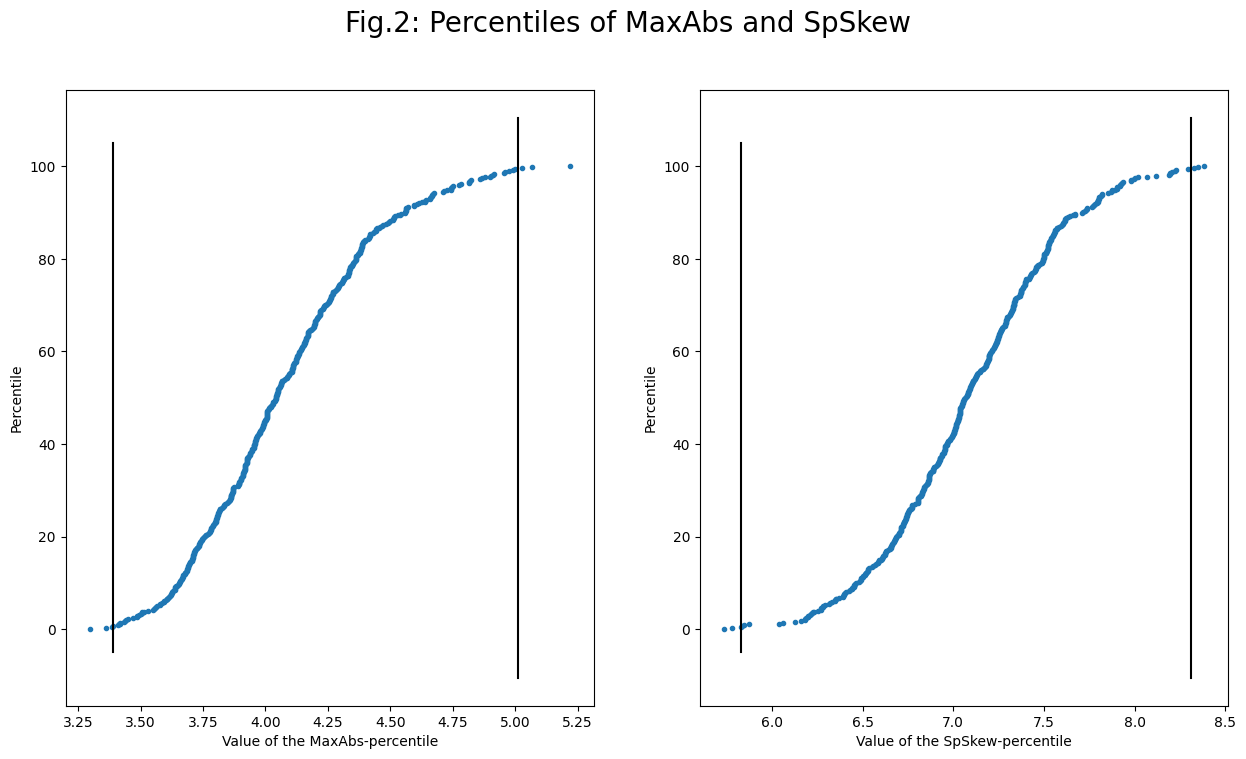

In [35]:
plt.figure(1, figsize=(15, 8))
plt.clf()
plt.suptitle("Fig.2: Percentiles of MaxAbs and SpSkew", fontsize=20)
plt.subplot(1, 2, 1)
plt.plot(
    np.sort(train_moments.loc[:, "MaxAbs"]), train_percentage, marker=".", linewidth=0
)
plt.plot([limit_max_abs[0], limit_max_abs[0]], plt.ylim(), color="k")
plt.plot([limit_max_abs[1], limit_max_abs[1]], plt.ylim(), color="k")
plt.xlabel("Value of the MaxAbs-percentile")
plt.ylabel("Percentile")
plt.subplot(1, 2, 2)
plt.plot(
    np.sort(train_moments.loc[:, "SpSkew"]), train_percentage, marker=".", linewidth=0
)
plt.plot([limit_sp_skew[0], limit_sp_skew[0]], plt.ylim(), color="k")
plt.plot([limit_sp_skew[1], limit_sp_skew[1]], plt.ylim(), color="k")
plt.xlabel("Value of the SpSkew-percentile")
plt.ylabel("Percentile")


Text(0, 0.5, 'Percentile')

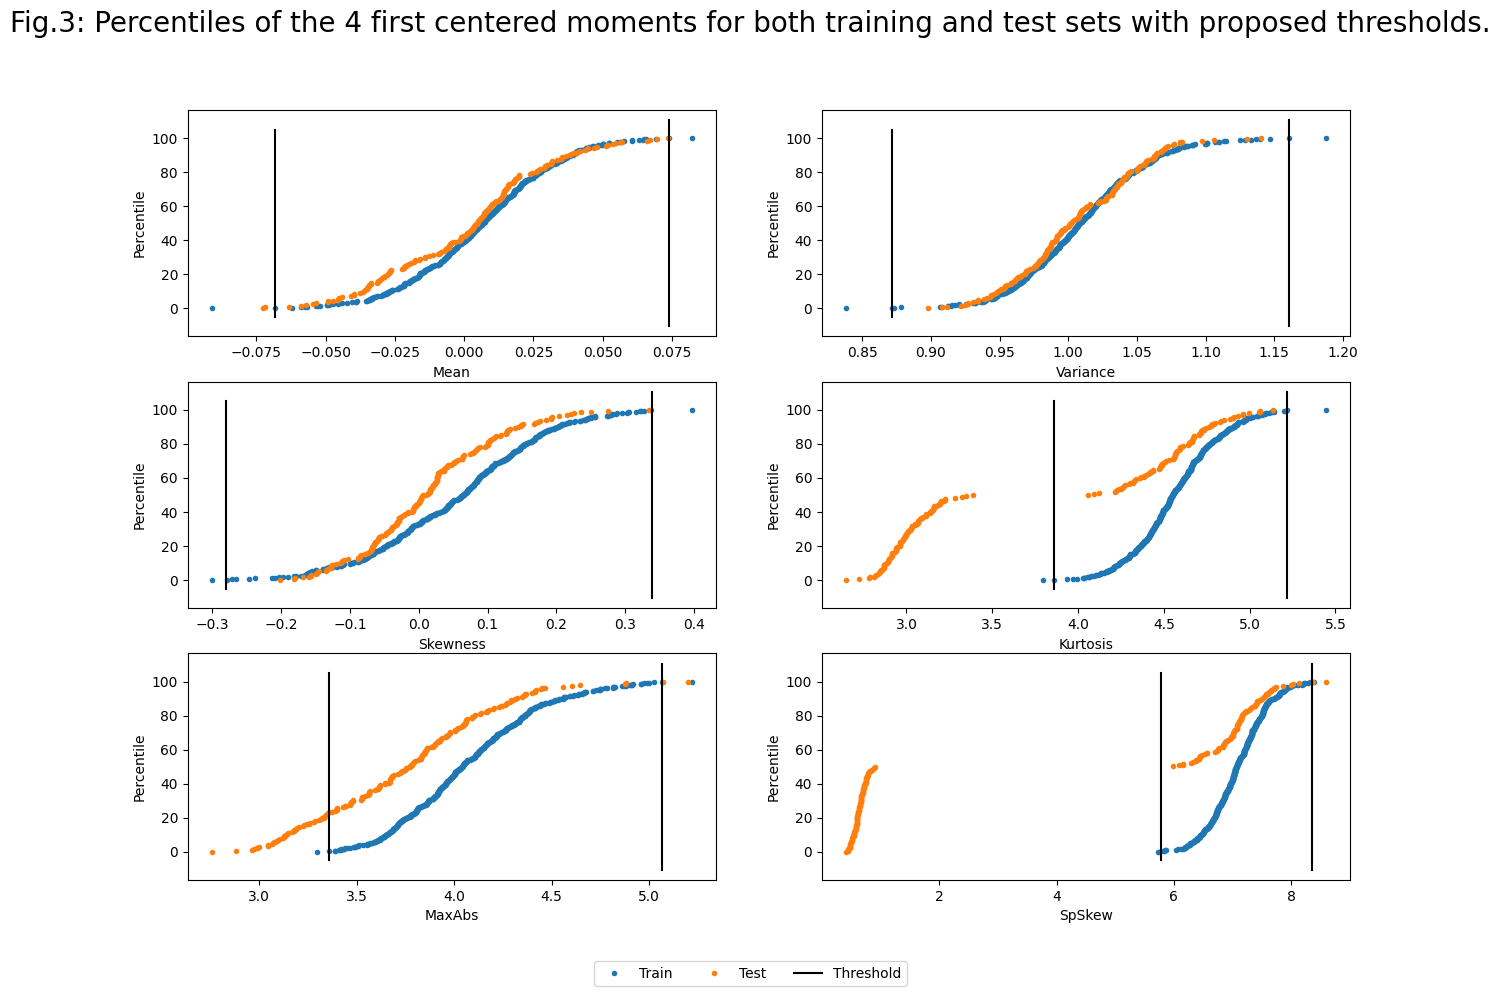

In [36]:
quantiles = [0.2, 99.8]
limit_max_abs = np.percentile(train_moments.loc[:, "MaxAbs"], quantiles)
limit_mean = np.percentile(train_moments.loc[:, "Mean"], quantiles)
limit_variance = np.percentile(train_moments.loc[:, "Variance"], quantiles)
lim_skew = np.percentile(train_moments.loc[:, "Skewness"], quantiles)
limit_kurtosis = np.percentile(train_moments.loc[:, "Kurtosis"], quantiles)
limit_sp_skew = np.percentile(train_moments.loc[:, "SpSkew"], quantiles)

test_percentage = np.linspace(
    0, 100, test_set_size
)  # from 0% to 100% with step 100/nTrain

plt.figure(2, figsize=(15, 10))
plt.clf()
plt.suptitle(
    "Fig.3: Percentiles of the 4 first centered moments "
    + "for both training and test sets with proposed thresholds.",
    fontsize=20,
)
plt.subplot(3, 2, 1)
plt.plot(
    np.sort(train_moments.loc[:, "Mean"]), train_percentage, marker=".", linewidth=0
)
plt.plot(np.sort(test_moments.loc[:, "Mean"]), test_percentage, marker=".", linewidth=0)
plt.plot([limit_mean[0], limit_mean[0]], plt.ylim(), color="k")
plt.plot([limit_mean[1], limit_mean[1]], plt.ylim(), color="k")
plt.xlabel("Mean")
plt.ylabel("Percentile")

plt.subplot(3, 2, 2)
plt.plot(
    np.sort(train_moments.loc[:, "Variance"]), train_percentage, marker=".", linewidth=0
)
plt.plot(
    np.sort(test_moments.loc[:, "Variance"]), test_percentage, marker=".", linewidth=0
)
plt.plot([limit_variance[0], limit_variance[0]], plt.ylim(), color="k")
plt.plot([limit_variance[1], limit_variance[1]], plt.ylim(), color="k")
plt.xlabel("Variance")
plt.ylabel("Percentile")

plt.subplot(3, 2, 3)
plt.plot(
    np.sort(train_moments.loc[:, "Skewness"]), train_percentage, marker=".", linewidth=0
)
plt.plot(
    np.sort(test_moments.loc[:, "Skewness"]), test_percentage, marker=".", linewidth=0
)
plt.plot([lim_skew[0], lim_skew[0]], plt.ylim(), color="k")
plt.plot([lim_skew[1], lim_skew[1]], plt.ylim(), color="k")
plt.xlabel("Skewness")
plt.ylabel("Percentile")
# plt.xlim([-50,50])

plt.subplot(3, 2, 4)
plt.plot(
    np.sort(train_moments.loc[:, "Kurtosis"]), train_percentage, marker=".", linewidth=0
)
plt.plot(
    np.sort(test_moments.loc[:, "Kurtosis"]), test_percentage, marker=".", linewidth=0
)
plt.plot([limit_kurtosis[0], limit_kurtosis[0]], plt.ylim(), color="k")
plt.plot([limit_kurtosis[1], limit_kurtosis[1]], plt.ylim(), color="k")
plt.xlabel("Kurtosis")
plt.ylabel("Percentile")
# plt.xlim([-50,5000])
plt.figlegend(
    ["Train", "Test", "Threshold"], loc="lower center", ncol=5, labelspacing=0.0
)

plt.subplot(3, 2, 5)
plt.plot(
    np.sort(train_moments.loc[:, "MaxAbs"]), train_percentage, marker=".", linewidth=0
)
plt.plot(
    np.sort(test_moments.loc[:, "MaxAbs"]), test_percentage, marker=".", linewidth=0
)
plt.plot([limit_max_abs[0], limit_max_abs[0]], plt.ylim(), color="k")
plt.plot([limit_max_abs[1], limit_max_abs[1]], plt.ylim(), color="k")
plt.xlabel("MaxAbs")
plt.ylabel("Percentile")

plt.subplot(3, 2, 6)
plt.plot(
    np.sort(train_moments.loc[:, "SpSkew"]), train_percentage, marker=".", linewidth=0
)
plt.plot(
    np.sort(test_moments.loc[:, "SpSkew"]), test_percentage, marker=".", linewidth=0
)
plt.plot([limit_sp_skew[0], limit_sp_skew[0]], plt.ylim(), color="k")
plt.plot([limit_sp_skew[1], limit_sp_skew[1]], plt.ylim(), color="k")
plt.xlabel("SpSkew")
plt.ylabel("Percentile")


In [37]:
# select points either below 0.5 percentile or above 99.5 percentile of each moments and min-max limits
abn_train_mean = np.where(
    (train_moments.loc[:, "Mean"] < limit_mean[0])
    | (train_moments.loc[:, "Mean"] > limit_mean[1])
)[0] #np.where extracts row number where conditions are true and [0] extracts the indices array from the tuple returned by np.where
abn_train_variance = np.where(
    (train_moments.loc[:, "Variance"] < limit_variance[0])
    | (train_moments.loc[:, "Variance"] > limit_variance[1])
)[0]
abn_train_skew = np.where(
    (train_moments.loc[:, "Skewness"] < lim_skew[0])
    | (train_moments.loc[:, "Skewness"] > lim_skew[1])
)[0]
abn_train_kurtosis = np.where(
    (train_moments.loc[:, "Kurtosis"] < limit_kurtosis[0])
    | (train_moments.loc[:, "Kurtosis"] > limit_kurtosis[1])
)[0]

abn_train_max_abs = np.where(
    (train_moments.loc[:, "MaxAbs"] < limit_max_abs[0])
    | (train_moments.loc[:, "MaxAbs"] > limit_max_abs[1])
)[0]
abn_train_sp_skew = np.where(
    (train_moments.loc[:, "SpSkew"] < limit_sp_skew[0])
    | (train_moments.loc[:, "SpSkew"] > limit_sp_skew[1])
)[0]

all_abnormalities_train = np.unique(
    np.concatenate(
        (
            abn_train_mean,
            abn_train_variance,
            abn_train_skew,
            abn_train_kurtosis,
            abn_train_max_abs,
            abn_train_sp_skew,
        )
    )
) # np.concatenate combines all flagged row numbers into one array and np.unique filters out duplicates in case a row was selected for multiple features

# Compare sets together. Loop over each pair of sets and compute how many IDs they have in common
train_dict = {
    "Mean": abn_train_mean,
    "Variance": abn_train_variance,
    "Skewness": abn_train_skew,
    "Kurtsosis": abn_train_kurtosis,
    "MaxAbs": abn_train_max_abs,
    "SpSkew": abn_train_sp_skew,
}
train_dict_keys = list(train_dict.keys()) # Creates a dictionary where each feature is associated with its array of abnormal rows

print("TRAINING DATASET")
for i in range(train_dict.__len__()):
    k1 = train_dict_keys[i]
    print("{}: {} anomalies found.".format(k1, train_dict[k1].__len__()))

anomalies_count_train = np.array(
    [np.sum([i in train_dict[k] for k in train_dict]) for i in range(train_set_size)]
)
for i in range(1, 5):
    print(
        "{} samples are found as anomalous by at least {} selection methods.".format(
            len(np.where(anomalies_count_train >= i)[0]), i
        )
    )

######################################################################################################

# select points either below 0.2 percentile or above 99.8 percentile of each moments and min-max limits
abn_test_mean = np.where(
    (test_moments.loc[:, "Mean"] < limit_mean[0])
    | (test_moments.loc[:, "Mean"] > limit_mean[1])
)[0]
abn_test_variance = np.where(
    (test_moments.loc[:, "Variance"] < limit_variance[0])
    | (test_moments.loc[:, "Variance"] > limit_variance[1])
)[0]
abn_test_skew = np.where(
    (test_moments.loc[:, "Skewness"] < lim_skew[0])
    | (test_moments.loc[:, "Skewness"] > lim_skew[1])
)[0]
abn_test_kurtosis = np.where(
    (test_moments.loc[:, "Kurtosis"] < limit_kurtosis[0])
    | (test_moments.loc[:, "Kurtosis"] > limit_kurtosis[1])
)[0]

abn_test_max_abs = np.where(
    (test_moments.loc[:, "MaxAbs"] < limit_max_abs[0])
    | (test_moments.loc[:, "MaxAbs"] > limit_max_abs[1])
)[0]
abn_test_sp_skew = np.where(
    (test_moments.loc[:, "SpSkew"] < limit_sp_skew[0])
    | (test_moments.loc[:, "SpSkew"] > limit_sp_skew[1])
)[0]

allAbnormalities = np.unique(
    np.concatenate(
        (
            abn_test_mean,
            abn_test_variance,
            abn_test_skew,
            abn_test_kurtosis,
            abn_test_max_abs,
            abn_test_sp_skew,
        )
    )
)


# compare sets together. Here I loop over each pair of set and compute how many ID they have in common
test_dict = {
    "Mean": abn_test_mean,
    "Variance": abn_test_variance,
    "Skewness": abn_test_skew,
    "Kurtosis": abn_test_kurtosis,
    "MaxAbs": abn_test_max_abs,
    "SpSkew": abn_test_sp_skew,
}
keysTest = list(test_dict.keys())


print("\nTEST DATASET")
for ii in range(test_dict.__len__()):
    k1 = keysTest[ii]
    print(f"{k1}: {len(test_dict[k1])} anomalies found.")

countAbnormalTest = np.array(
    [np.sum([i in test_dict[k] for k in test_dict]) for i in range(test_set_size)]
)
for i in range(1, 5):
    print(
        f"{len(np.where(countAbnormalTest >= i)[0])} samples are found as anomalous "
        f"by at least {i} selection methods."
    )


TRAINING DATASET
Mean: 2 anomalies found.
Variance: 2 anomalies found.
Skewness: 2 anomalies found.
Kurtsosis: 2 anomalies found.
MaxAbs: 2 anomalies found.
SpSkew: 2 anomalies found.
12 samples are found as anomalous by at least 1 selection methods.
0 samples are found as anomalous by at least 2 selection methods.
0 samples are found as anomalous by at least 3 selection methods.
0 samples are found as anomalous by at least 4 selection methods.

TEST DATASET
Mean: 2 anomalies found.
Variance: 0 anomalies found.
Skewness: 0 anomalies found.
Kurtosis: 100 anomalies found.
MaxAbs: 48 anomalies found.
SpSkew: 102 anomalies found.
105 samples are found as anomalous by at least 1 selection methods.
100 samples are found as anomalous by at least 2 selection methods.
45 samples are found as anomalous by at least 3 selection methods.
2 samples are found as anomalous by at least 4 selection methods.


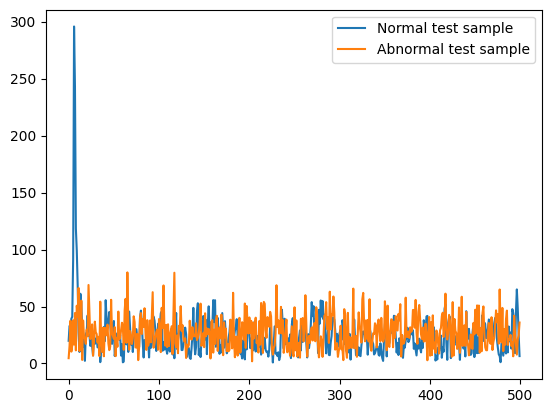

In [38]:
fft = np.abs(np.fft.fft(train_set[1]))[: train_set_timesteps // 2]
plt.plot(fft, label="Normal test sample")
fft = np.abs(np.fft.fft(test_set[0]))[: test_set_timesteps // 2]
plt.plot(fft, label="Abnormal test sample")
plt.legend()


Text(0.5, 1.0, 'Test dataset')

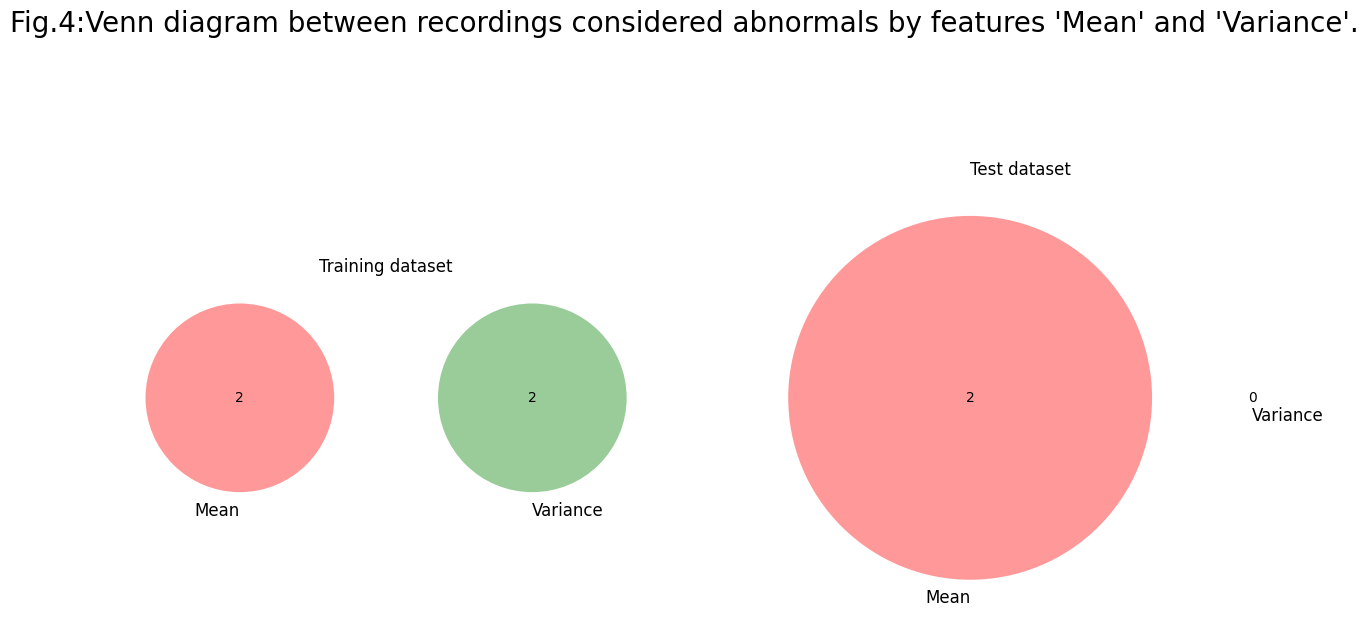

In [39]:
plt.figure(3, figsize=(15, 8))
plt.clf() # Clears figure, removing any previous plots
plt.suptitle(
    "Fig.4:Venn diagram between recordings considered abnormals by features 'Mean' and 'Variance'.",
    fontsize=20,
) # Supertitle for the whole plot

loc_train_mean = (train_moments.loc[:, "Mean"] < limit_mean[0]) | (
    train_moments.loc[:, "Mean"] > limit_mean[1]
) #Gives Boolean results if value is outside of limit
loc_train_variance = (train_moments.loc[:, "Variance"] < limit_variance[0]) | (
    train_moments.loc[:, "Variance"] > limit_variance[1]
)
a1 = np.sum(loc_train_mean & loc_train_variance) # Counts abnormal samples in mean and variance
a2 = np.sum(loc_train_mean & ~loc_train_variance) # Counts abnormal samples in mean and not (~) variance
a3 = np.sum(~loc_train_mean & loc_train_variance) # Counts abnormal samples in not (~) mean and variance

plt.subplot(121) # Plot with one row, two columns, first plot
venn2(subsets=(a2, a3, a1), set_labels=("Mean", "Variance"))
plt.title("Training dataset")

# Repeat the same for the test dataset

loc_test_mean = (test_moments.loc[:, "Mean"] < limit_mean[0]) | (
    test_moments.loc[:, "Mean"] > limit_mean[1]
)
loc_test_variance = (test_moments.loc[:, "Variance"] < limit_variance[0]) | (
    test_moments.loc[:, "Variance"] > limit_variance[1]
)
a1 = np.sum(loc_test_mean & loc_test_variance)
a2 = np.sum(loc_test_mean & ~loc_test_variance)
a3 = np.sum(~loc_test_mean & loc_test_variance)


plt.subplot(122)
venn2(subsets=(a2, a3, a1), set_labels=("Mean", "Variance"))
plt.title("Test dataset")


Text(0.5, 1.0, 'Test dataset')

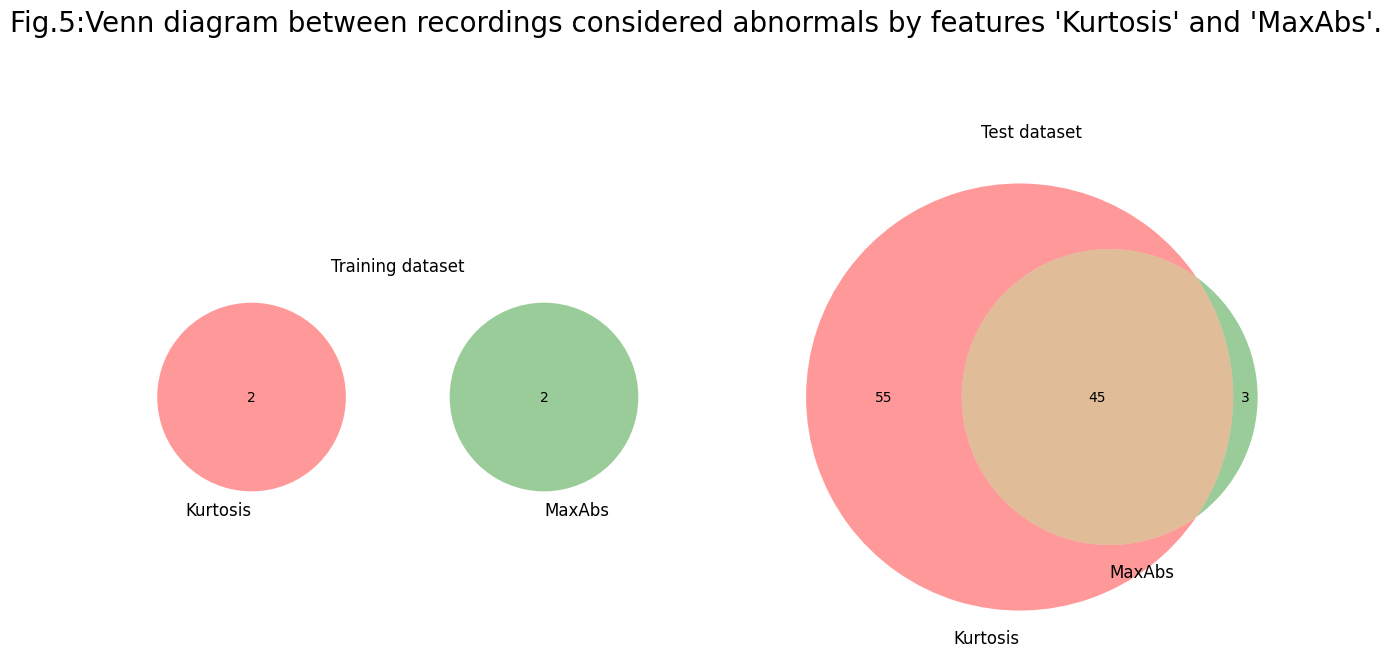

In [40]:
plt.figure(3, figsize=(15, 8))
plt.clf()
plt.suptitle(
    "Fig.5:Venn diagram between recordings considered abnormals by features 'Kurtosis' and 'MaxAbs'.",
    fontsize=20,
)

loc_train_kurtosis = (train_moments.loc[:, "Kurtosis"] < limit_kurtosis[0]) | (
    train_moments.loc[:, "Kurtosis"] > limit_kurtosis[1]
)
loc_train_max_abs = (train_moments.loc[:, "MaxAbs"] < limit_max_abs[0]) | (
    train_moments.loc[:, "MaxAbs"] > limit_max_abs[1]
)
a1 = np.sum(loc_train_kurtosis & loc_train_max_abs)
a2 = np.sum(loc_train_kurtosis & ~loc_train_max_abs)
a3 = np.sum(~loc_train_kurtosis & loc_train_max_abs)

plt.subplot(121)
venn2(subsets=(a2, a3, a1), set_labels=("Kurtosis", "MaxAbs"))
plt.title("Training dataset")


loc_test_kurtosis = (test_moments.loc[:, "Kurtosis"] < limit_kurtosis[0]) | (
    test_moments.loc[:, "Kurtosis"] > limit_kurtosis[1]
)
loc_test_max_abs = (test_moments.loc[:, "MaxAbs"] < limit_max_abs[0]) | (
    test_moments.loc[:, "MaxAbs"] > limit_max_abs[1]
)
a1 = np.sum(loc_test_kurtosis & loc_test_max_abs)
a2 = np.sum(loc_test_kurtosis & ~loc_test_max_abs)
a3 = np.sum(~loc_test_kurtosis & loc_test_max_abs)


plt.subplot(122)
venn2(subsets=(a2, a3, a1), set_labels=("Kurtosis", "MaxAbs"))
plt.title("Test dataset")


Text(0.5, 1.0, 'Test dataset')

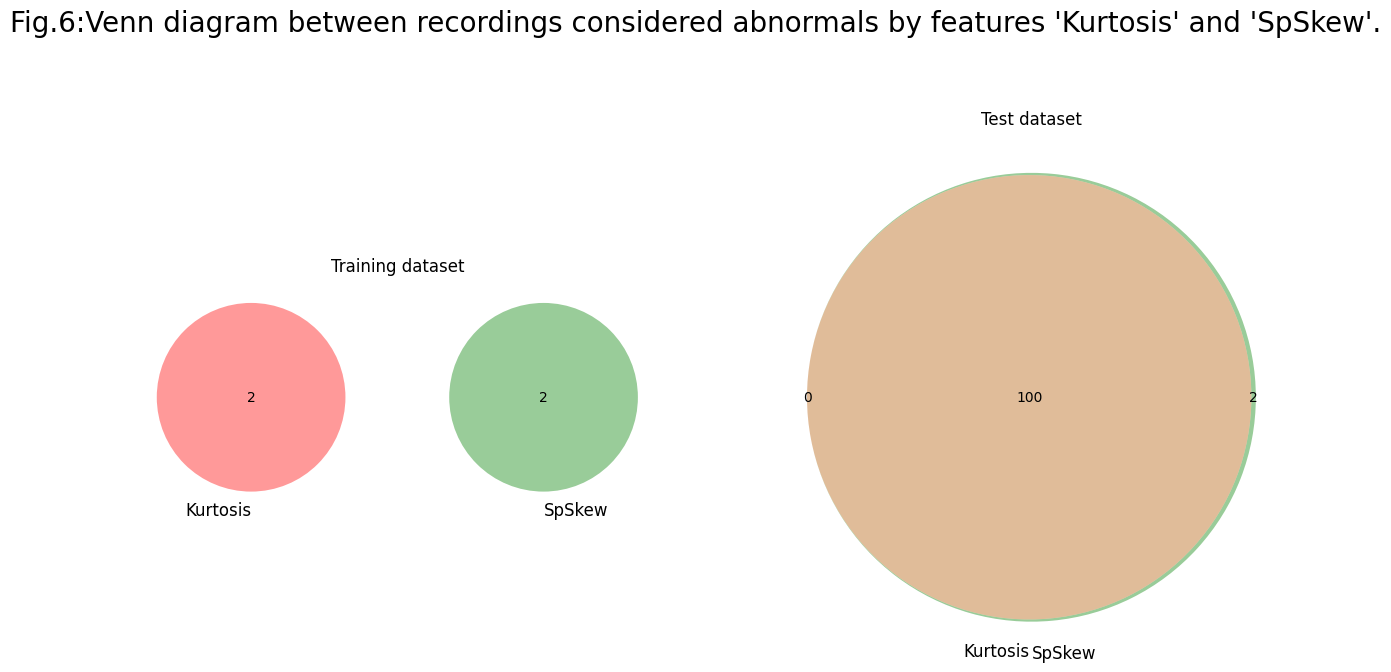

In [41]:
plt.figure(3, figsize=(15, 8))
plt.clf()
plt.suptitle(
    "Fig.6:Venn diagram between recordings considered abnormals by features 'Kurtosis' and 'SpSkew'.",
    fontsize=20,
)

loc_train_kurtosis = (train_moments.loc[:, "Kurtosis"] < limit_kurtosis[0]) | (
    train_moments.loc[:, "Kurtosis"] > limit_kurtosis[1]
)
loc_train_sp_skew = (train_moments.loc[:, "SpSkew"] < limit_sp_skew[0]) | (
    train_moments.loc[:, "SpSkew"] > limit_sp_skew[1]
)
a1 = np.sum(loc_train_kurtosis & loc_train_sp_skew)
a2 = np.sum(loc_train_kurtosis & ~loc_train_sp_skew)
a3 = np.sum(~loc_train_kurtosis & loc_train_sp_skew)

plt.subplot(121)
venn2(subsets=(a2, a3, a1), set_labels=("Kurtosis", "SpSkew"))
plt.title("Training dataset")


loc_test_kurtosis = (test_moments.loc[:, "Kurtosis"] < limit_kurtosis[0]) | (
    test_moments.loc[:, "Kurtosis"] > limit_kurtosis[1]
)
loc_test_sp_skew = (test_moments.loc[:, "SpSkew"] < limit_sp_skew[0]) | (
    test_moments.loc[:, "SpSkew"] > limit_sp_skew[1]
)
a1 = np.sum(loc_test_kurtosis & loc_test_sp_skew)
a2 = np.sum(loc_test_kurtosis & ~loc_test_sp_skew)
a3 = np.sum(~loc_test_kurtosis & loc_test_sp_skew)


plt.subplot(122)
venn2(subsets=(a2, a3, a1), set_labels=("Kurtosis", "SpSkew"))
plt.title("Test dataset")


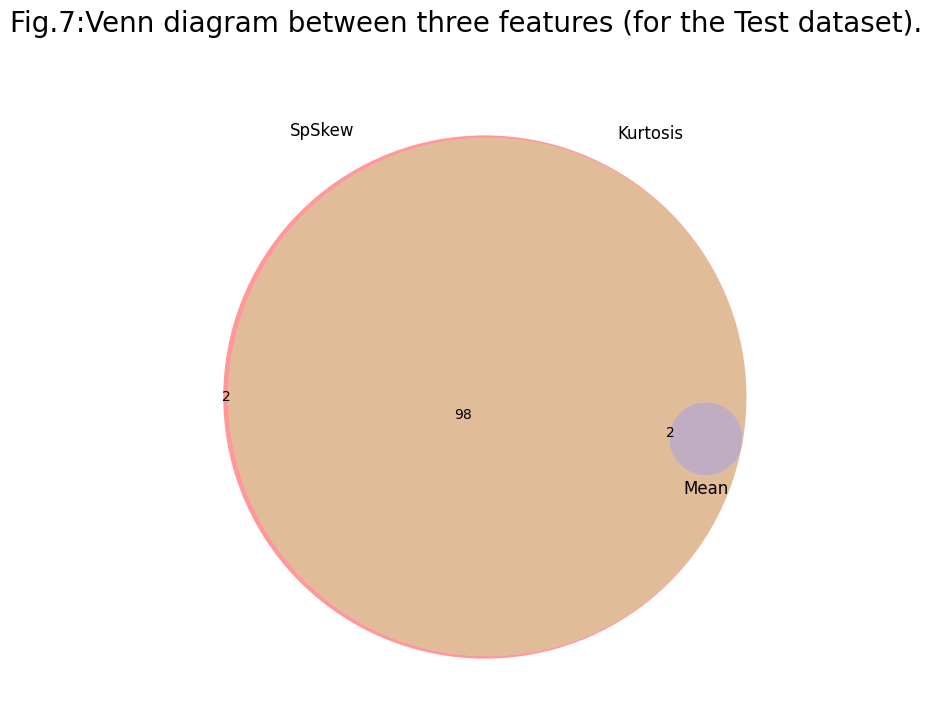

In [42]:
loc_test_kurtosis = (test_moments.loc[:, "Kurtosis"] < limit_kurtosis[0]) | (
    test_moments.loc[:, "Kurtosis"] > limit_kurtosis[1]
)
loc_test_mean = (test_moments.loc[:, "Mean"] < limit_mean[0]) | (
    test_moments.loc[:, "Mean"] > limit_mean[1]
)
loc_test_sp_skew = (test_moments.loc[:, "SpSkew"] < limit_sp_skew[0]) | (
    test_moments.loc[:, "SpSkew"] > limit_sp_skew[1]
)

a1 = np.sum((loc_test_sp_skew & ~loc_test_kurtosis) & ~loc_test_mean)
a2 = np.sum((~loc_test_sp_skew & loc_test_kurtosis) & ~loc_test_mean)
a3 = np.sum((loc_test_sp_skew & loc_test_kurtosis) & ~loc_test_mean)
a4 = np.sum((~loc_test_sp_skew & ~loc_test_kurtosis) & loc_test_mean)
a5 = np.sum((loc_test_sp_skew & ~loc_test_kurtosis) & loc_test_mean)
a6 = np.sum((~loc_test_sp_skew & loc_test_kurtosis) & loc_test_mean)
a7 = np.sum((loc_test_sp_skew & loc_test_kurtosis) & loc_test_mean)

plt.figure(4, figsize=(15, 8))
plt.clf()
plt.suptitle(
    "Fig.7:Venn diagram between three features (for the Test dataset).", fontsize=20
)

venn3(subsets=(a1, a2, a3, a4, a5, a6, a7), set_labels=("SpSkew", "Kurtosis", "Mean"))


---

## Part 1: Feature-based Anomaly Detection

⚠️ **This part contains the first part of the graded questions.** ⚠️

Find your own features for a real acoustic dataset from industrial machines!

Acoustic emission and vibration monitoring play integral roles in structural health 
monitoring (SHM) by providing crucial insights into the condition and integrity of 
structures. Acoustic Emission involves the detection of transient stress waves or 
acoustic signals emitted by materials when they undergo deformation or damage. Vibration 
monitoring with accelerometers is widely used to assess the structural integrity of 
various systems, from bridges and buildings to rotating machinery. Vibration analysis 
can reveal changes in natural frequencies, mode shapes, and damping characteristics, 
which can be indicative of structural damage or degradation. 

**Dataset Description*

For this exercise, we consider acoustic emissions from two machines: a **pump** and a 
**valve**. The datasets come as follows:

* **pump**
    * train set containing data from pump in good working conditions
    * test set containing both healthy data and data from pumps with abnormal behaviors
* **valve**
    * train set containing data from valve in good working conditions
    * test set containing both healthy data and data from valves with abnormal behaviors

**Problem Description**

Using features introduced in [Part 0](#part-0-demonstration), other features presented 
during lectures and previous exercises, or any other features you deem useful, your goal
is to identify features that can uncover anomalies present in the test dataset but not 
present in the training dataset. Selected features will be different for the pump and 
valve.

### Questions

**Question 1:** Generate plots of raw signals, FFT spectrums or spectrogram from the 
healthy data of both the pump and valve acoustic signals. Discuss the distinctions 
between the signals emitted by these two machines.

Questions 2, 3 and 4 have to be answered separately for both the pump and valve datasets.

**Question 2:** Visualize the raw signals, spectrum, and spectrograms of the test 
dataset for the pump/valve dataset. Are there any signals that appear abnormal to you?

**Question 3:** Compute basic statistical features (mean, variance, skewness, and 
kurtosis) for both the training and test datasets of the pump and valve. Are there any 
abnormal signals that you can detect?

**Question 4:** Find by yourself a feature or a combination of feature that help to 
uncover signals with abnormal behavior. Analyze whether the selected features trigger 
alarms for similar behavior or if some are specific to particular anomalies.

**Question 5:** What are some potential limitations of the method suggested in this 
exercise for anomaly detection? Answer with at least 3 limitations.

**Question 6:** Now that you have developed a set of features and thresholds for a 
valve/pump, imagine applying them to a different valve/pump. Would the discriminative 
power change? If so, how do you propose to mitigate it? Justify and provide concrete 
details.

**Question 7:** Now imagine you're in a scenario where the are no anomalous samples 
available. How would you tackle this problem? Answer with an overview of your proposed 
approach and then provide concrete details regarding the method.


The answers to those questions are expected in a **PDF report**. The full Jupyter notebook 
must also be submitted. A PDF report without any description, analysis, and discussion 
around the plots will not be considered valid.

**Critical Points & Requirements**

Here is a unorded non-exhaustive list of some critical points which will be taken into 
account for grading:
- Quality of the plots (legend, axes labels, plot titles, units, ...)
- Discriminative power of the selected features (performance) on the `valve` dataset
- Discriminative power of the selected features (performance) on the `pump` dataset
- Quality of the scientific reasoning
- Structure, clarity, and conciseness of the report
- Quality of the code (useful but concise documentation, clarity of the code, ...)
- ...

⚠️ Your submitted notebook should be able to run on a properly configured environment
(*c.f.* intro to assignment 0).

### 0. Download the Dataset

``gdown`` is a Python library and command-line tool that simplifies the process of downloading files from Google Drive.
The files are downloaded only if necessary.

In [43]:
# Pump dataset
os.makedirs("part_1", exist_ok=True)
if not os.path.isdir("part_1/pump") and not os.path.isfile("part_1/pump.zip"):
    gdown.download(id="1Vz1fhpu5xKJ4RI5maJh_3OweX9BpjBaM", output="./part_1/pump.zip")


In [44]:
# Valve dataset
if not os.path.isdir("part_1/valve") and not os.path.isfile("part_1/valve.zip"):
    gdown.download(id="13bzdjL0gEc9hsGHjr0Qo8OMcMF5CrYbS", output="./part_1/valve.zip")


### 1. Extract the Dataset

In [45]:
# List all ZIP files in the current directory
zip_files = [file for file in os.listdir("./part_1") if file.endswith(".zip")]

# Loop through each ZIP file and unzip it in the same directory
for zip_file in zip_files:
    with zipfile.ZipFile(os.path.join("part_1", zip_file), "r") as zip_ref:
        zip_ref.extractall("part_1")

# Delete ZIP archives
for archive in zip_files:
    os.remove(os.path.join("part_1", archive))


### 2. Load the Audio Data

In this code cell, we are using the `librosa` library to load audio files from two 
directories: `/valve` and `/pump`. The goal is to prepare audio data for further 
analysis or processing.


In [46]:
def load_wav_files(directory: str) -> np.ndarray:
    """Load all .WAV audio files in a directory as a 2D Numpy array

    Args:
        directory (str): Path to the directory containing the audio files

    Returns:
        np.ndarray: Loaded audio files as a 2D array
    """
    audio_data: list = []

    # Iterate through files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".wav") or filename.endswith(".WAV"):
            file_path = os.path.join(directory, filename)

            # Load audio file and append it to the list
            audio, sr = librosa.load(file_path, sr=None)
            audio_data.append(audio)

    return np.array(audio_data)


# Paths to the "valve" and "pump" directories
valve_directory = "./part_1/valve"
pump_directory = "./part_1/pump"

# Load audio data for "valve" and "pump"
valve_train_data = load_wav_files(os.path.join(valve_directory, "train"))
valve_test_data = load_wav_files(os.path.join(valve_directory, "test"))
pump_train_data = load_wav_files(os.path.join(pump_directory, "train"))
pump_test_data = load_wav_files(os.path.join(pump_directory, "test"))


In [47]:
print(f"Valve Train Data Shape: {valve_train_data.shape}")
print(f"Valve Test Data Shape: {valve_test_data.shape}")
print(f"Pump Train Data Shape: {pump_train_data.shape}")
print(f"Pump Test Data Shape: {pump_test_data.shape}")


Valve Train Data Shape: (500, 160000)
Valve Test Data Shape: (219, 160000)
Pump Train Data Shape: (200, 160000)
Pump Test Data Shape: (200, 160000)


⚠️ **You're expected to fill the notebook from here.** ⚠️

### Answers to Part 1


In [48]:
# TODO: Add all your necessary code to answer part 1
# Feel free to add multiple code or markdown cells


NameError: name 'STOP' is not defined

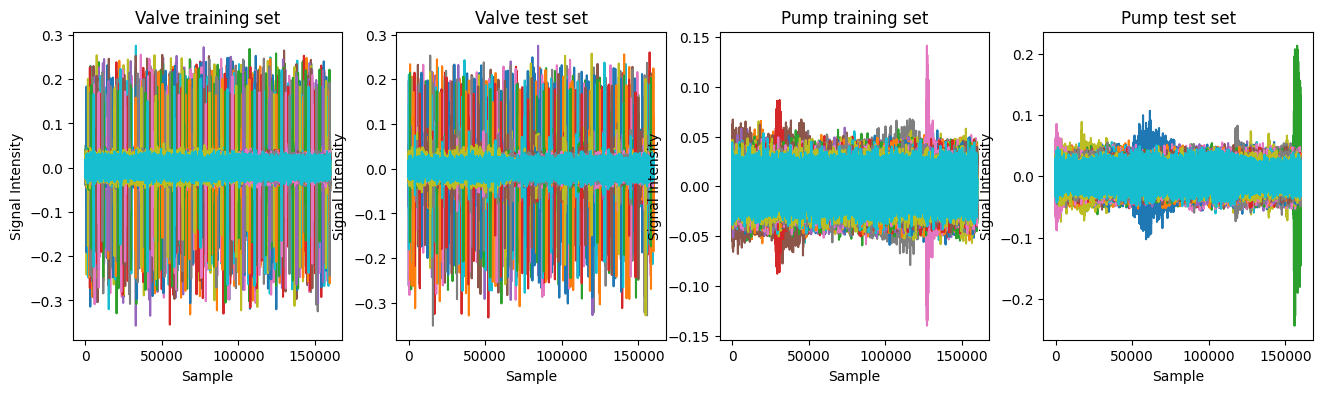

In [65]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i in range(100):
    ax[0].plot(valve_train_data[i])
    ax[0].set_title("Valve training set")
    ax[1].plot(valve_test_data[i])
    ax[1].set_title("Valve test set")
    ax[2].plot(pump_train_data[i])
    ax[2].set_title("Pump training set")
    ax[3].plot(pump_test_data[i])
    ax[3].set_title("Pump test set")

for i in range(4):
    ax[i].set_xlabel("Sample")
    ax[i].set_ylabel("Signal Intensity")


Calculating the absolute value for the valve dataset:

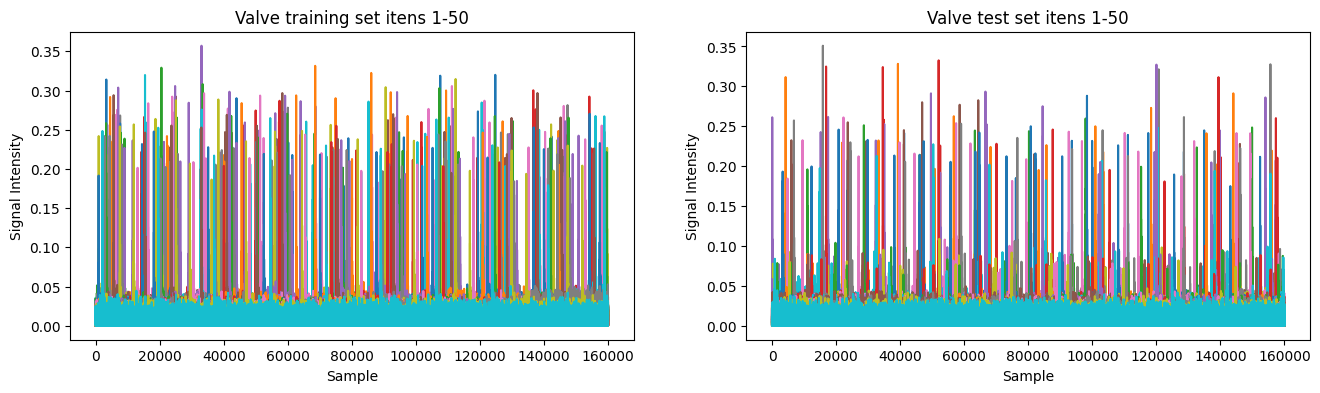

In [66]:
train_set_abs_valve = np.abs(valve_train_data)
test_set_abs_valve = np.abs(valve_test_data)
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for i in range(50):
    ax[0].plot(train_set_abs_valve[i])
    ax[0].set_title("Valve training set itens 1-50")
    ax[1].plot(test_set_abs_valve[i])
    ax[1].set_title("Valve test set itens 1-50")

for i in range(2):
    ax[i].set_xlabel("Sample")
    ax[i].set_ylabel("Signal Intensity")

Calculating the absolute value for the pump dataset:

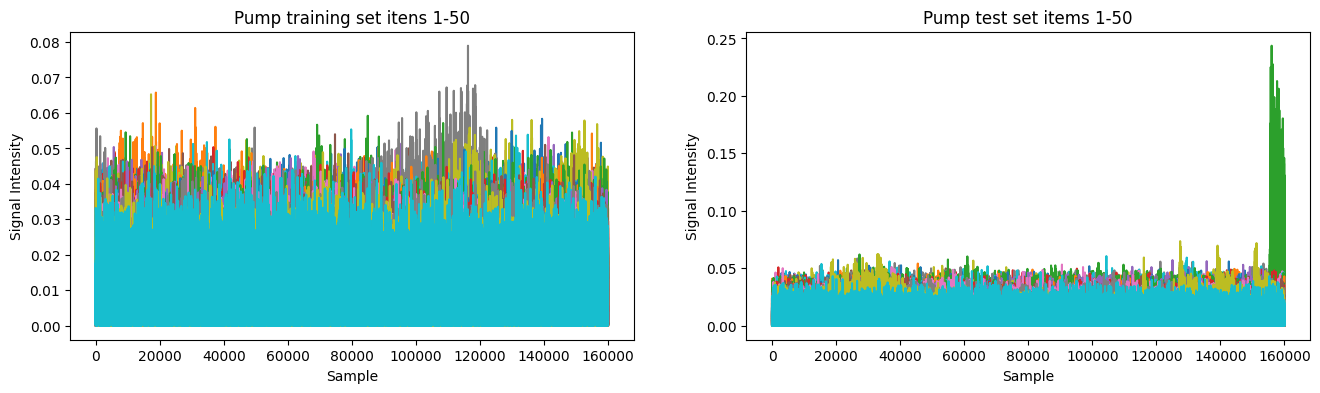

In [67]:
train_set_abs_pump = np.abs(pump_train_data)
test_set_abs_pump = np.abs(pump_test_data)
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
for i in range(50):
    ax[0].plot(train_set_abs_pump[i])
    ax[0].set_title("Pump training set itens 1-50")
    ax[1].plot(test_set_abs_pump[i])
    ax[1].set_title("Pump test set items 1-50")


for i in range(2):
    ax[i].set_xlabel("Sample")
    ax[i].set_ylabel("Signal Intensity")

In [69]:
# Compute moments 1 to 4 on the training set and assign them in a Pandas dataframe
train_moments_valve = pd.DataFrame(
    {
        "MaxAbs": np.amax(train_set_abs_valve, axis=1),
        "Mean": np.mean(valve_train_data, axis=1),
        "Variance": scist.moment(valve_train_data, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(valve_train_data, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            valve_train_data, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "train",
    }
)

# Compute moments 1 to 4 on the testing set and assign them in a Pandas dataframe
test_moments_valve = pd.DataFrame(
    {
        "MaxAbs": np.amax(test_set_abs_valve, axis=1),
        "Mean": np.mean(valve_test_data, axis=1),
        "Variance": scist.moment(valve_test_data, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(valve_test_data, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            valve_test_data, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "test",
    }
)


In [70]:
# Compute moments 1 to 4 on the training set and assign them in a Pandas dataframe
train_moments_pump = pd.DataFrame(
    {
        "MaxAbs": np.amax(train_set_abs_pump, axis=1),
        "Mean": np.mean(pump_train_data, axis=1),
        "Variance": scist.moment(pump_train_data, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(pump_train_data, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            pump_train_data, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "train",
    }
)

# Compute moments 1 to 4 on the testing set and assign them in a Pandas dataframe
test_moments_pump = pd.DataFrame(
    {
        "MaxAbs": np.amax(train_set_abs_pump, axis=1),
        "Mean": np.mean(pump_train_data, axis=1),
        "Variance": scist.moment(pump_train_data, moment=2, axis=1, nan_policy="propagate"),
        "Skewness": scist.skew(pump_train_data, axis=1, bias=True, nan_policy="propagate"),
        "Kurtosis": scist.kurtosis(
            pump_train_data, axis=1, fisher=False, bias=True, nan_policy="propagate"
        ),
        "type": "test",
    }
)


In [74]:
valve_train_set_size = valve_train_data.shape[0]
valve_test_set_size = valve_test_data.shape[0]
pump_train_set_size = pump_train_data.shape[0]
pump_test_set_size = pump_test_data.shape[0]

print(valve_train_data)
print(valve_train_set_size)

# valves

train_spectrum_valve = 2.0 / valve_train_set_size * np.abs(fft(valve_train_data, axis=1, norm=None))
test_spectrum_valve = 2.0 / valve_test_set_size * np.abs(fft(valve_test_data, axis=1, norm=None))

# Compute Skewness of the Sprectrum excluding the 0 [Hz] component

valve_train_moments["SpSkew"] = scist.skew(
    train_spectrum_valve[:, 1:], axis=1, bias=True, nan_policy="propagate"
)
valve_test_moments["SpSkew"] = scist.skew(
    test_spectrum_valve[:, 1:], axis=1, bias=True, nan_policy="propagate"
)


# pumps
train_spectrum_pump = 2.0 / pump_train_set_size * np.abs(fft(pump_train_data, axis=1, norm=None))
test_spectrum_pump = 2.0 / pump_test_set_size * np.abs(fft(pump_test_data, axis=1, norm=None))

# Compute Skewness of the Sprectrum excluding the 0 [Hz] component

pump_train_moments["SpSkew"] = scist.skew(
    train_spectrum_pump[:, 1:], axis=1, bias=True, nan_policy="propagate"
)
pump_test_moments["SpSkew"] = scist.skew(
    test_spectrum_pump[:, 1:], axis=1, bias=True, nan_policy="propagate"
)

[[ 0.00585938  0.00680542  0.00335693 ... -0.00894165 -0.0138855
  -0.00839233]
 [-0.00100708  0.00668335  0.0116272  ... -0.00057983  0.00262451
   0.00253296]
 [ 0.00079346  0.012146    0.01885986 ... -0.0017395  -0.00076294
  -0.0007019 ]
 ...
 [-0.00946045  0.0027771   0.00653076 ...  0.01049805  0.00091553
   0.00424194]
 [ 0.0067749   0.00753784  0.00662231 ...  0.00079346  0.00714111
  -0.00152588]
 [-0.00045776 -0.00143433 -0.00595093 ...  0.01016235 -0.00613403
  -0.02099609]]
500


TypeError: 'numpy.ndarray' object is not callable

## Part 2: Classification-based Anomaly Detection

⚠️ **This part contains the second part of the graded questions.** ⚠️

We now treat anomaly detection as a **one-class classification** problem, where the 
model is trained on normal sound data to detect deviations from the learned pattern.

Anomalous sound detection can be achieved with following steps:
   - Feature Extraction (I)
   - One-class Classifier Training (II)
   - Decisions based on a threshold from your trained classifier (III)
   
Through this second part, you will primarily focus on tasks (I) and (II).
The quality of your one-class classifier will be assessed using the 
**Area Under the Curve (AUC)** score on the test dataset.

The model used here is a type of neural network called **AutoEncoder** (AE). AE is trained to reconstruct the input data while compressing the input data into a lower-dimensional latent space and minimizing information loss during this process.
Thus, you will also modify the extracted features and Neural Network used in this notebook to improve the anomalous sound detection performance.

### Questions

Your task is to improve the anomalous sound detection performance by modifying the feature extraction process and neural network architecture. You are expected to experiment with various feature representations and neural network configurations to optimize detection results.

Specifically, the following questions must be addressed. Each question should be discussed separately for both the Pump and Valve datasets. The answers are to be provided in a PDF report, and the full Jupyter notebook must also be submitted.

**Question 1:** Given the provided code, fill in the blank spaces to extract signal features, train a simple AutoEncoder that reconstructs the inputs MEL-Spectogram, and report the AUC score.

**Question 2:** From the trained AutoEncoder, use the bottleneck features to train both (1) a One-Class SVM and (2) an Isolation Forest, and report the corresponding AUC scores.

**Question 3:** Instead of using AutoEncoder features, apply PCA to project the MEL-spectrogram into a smaller dimensional space, then train (1) a One-Class SVM and (2) an Isolation Forest, and report the AUC scores.

**Question 4:** Determine an appropriate threshold for distinguishing anomalies based on the given results, and compute the following metrics: Accuracy, True Positive Rate (TPR), False Positive Rate (FPR), and F1-score.

**Question 5:** Visualize essential steps and provide a thorough discussion of the results obtained from all the methods.  

**Bonus Question:** Modify the AutoEncoder architecture to a 2D AutoEncoder using convolutional layers instead of fully connected layers, and analyze its performance.

### 0. Download and Extract the Dataset



In [ ]:
# Download labeled datasets
os.makedirs("part_2", exist_ok=True)
if not os.path.isdir("part_2/dev_data_pump_04") and not os.path.isfile(
    "part_2/dev_data_pump_04.zip"
):
    gdown.download(
        id="1ZAqnNW2gnHDyFHGHk3Aru7k-ng-BTpGn",
        output="./part_2/dev_data_pump_04.zip",
    )
if not os.path.isdir("part_2/dev_data_valve_00") and not os.path.isfile(
    "part_2/dev_data_valve_00.zip"
):
    gdown.download(
        id="1H_SS7qteLcd44e5CD9CFJjhJ573FAb6M",
        output="./part_2/dev_data_valve_00.zip",
    )

# List all ZIP files in the current directory
zip_files = [file for file in os.listdir("./part_2") if file.endswith(".zip")]

# Loop through each ZIP file and unzip it in the same directory
for zip_file in zip_files:
    with zipfile.ZipFile(os.path.join("part_2", zip_file), "r") as zip_ref:
        zip_ref.extractall("part_2")

# Delete ZIP archives
for archive in zip_files:
    os.remove(os.path.join("part_2", archive))


### 1. MEL Spectrogram Feature Extraction

In [ ]:
def load_wav_files(wav_file_name: str, mono: bool = True) -> tuple:
    """Load a .wav file."""
    try:
        return librosa.load(wav_file_name, sr=None, mono=mono)
    except Exception as e:
        print(f"Failed to load file '{wav_file_name}'. Error: {e}")
        raise e


def demux_wav_files(wav_file_name: str, channel: int = 0) -> tuple:
    """Demux a .wav file and return a specific channel."""
    try:
        multi_channel_data, sr = load_wav_files(wav_file_name, mono=False)
        if multi_channel_data.ndim == 1:
            return sr, multi_channel_data
        return sr, multi_channel_data[channel, :]
    except ValueError as e:
        print(f"Error in demuxing file '{wav_file_name}': {e}")
        raise


# Feel free to modify and analyse the images in your report
def plot_signals(
    tmin: int,
    tmax: int,
    sampling_rate: int,
    y: np.ndarray,
    emphasized_y,
    log_mel_spectrogram,
) -> None:
    plt.figure(1)
    n = len(y)
    t = np.linspace(tmin, tmax, n)
    plt.plot(t, y)
    plt.xlim(t[0], t[-1])
    plt.xlabel("time/s", fontsize=20)
    plt.ylabel("Amplitude", fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid()

    plt.figure(2)
    freq = sampling_rate / n * np.linspace(0, n / 2, int(n / 2) + 1)
    plt.plot(
        freq,
        np.absolute(np.fft.rfft(y[tmin * sampling_rate : tmax * sampling_rate], n) ** 2)
        / n,
    )
    plt.xlim(0, 5000)
    plt.xlabel("Frequency/Hz", fontsize=14)

    plt.figure(3)
    plt.plot(freq, np.absolute(np.fft.rfft(emphasized_y, n) ** 2) / n)
    plt.xlim(0, 5000)
    plt.xlabel("Frequency/Hz", fontsize=14)

    plt.figure(4)
    librosa.display.specshow(log_mel_spectrogram)
    plt.colorbar()


########################################################################
# Feature Extractor
########################################################################
def file_to_features(
    file_name, n_mels=64, frames=5, n_fft=1024, hop_length=512, power=2.0, plot=True
):
    """Convert a WAV file to a vector array."""
    # Step 01: Load the demuxed wav files
    sr, y = demux_wav_files(file_name, channel=0)

    # Step 02: Signal Pre-emphasis
    tmin = int(0)
    tmax = int(len(y) / sr)
    alpha = 0.95
    emphasized_y = np.append(y[0], y[1:] - alpha * y[:-1])

    # Step 03: Generate MEL-Spectrogram
    # ===================================
    # TODO: IMPLEMENT YOUR CODE HERE
    # ===================================

    # Step 04: Convert MEL-Spectrogram to log scale
    # ===================================
    # TODO: IMPLEMENT YOUR CODE HERE
    # ===================================

    # Step 05: Define Feature Vector Array
    dims = n_mels * frames
    length = len(log_mel_spectrogram[0, :]) - frames + 1
    features = np.zeros((length, dims), float)

    # Pad short clips instead of skipping
    if length < 1:
        print(f"Audio file '{file_name}' is too short. Padding applied.")
        log_mel_spectrogram = np.pad(
            log_mel_spectrogram, ((0, 0), (0, frames - 1)), mode="constant"
        )
        length = 1

    for t in range(frames):
        features[:, n_mels * t : n_mels * (t + 1)] = log_mel_spectrogram[
            :, t : t + length
        ].T

    if plot:
        plot_signals(tmin, tmax, sr, y, emphasized_y, log_mel_spectrogram)
    return features


In [ ]:
wav_test_file = "part_2/dev_data_pump_04/pump/train/normal_id_04_00000000.wav"
# wav_test_file = 'part_2/dev_data_pump_04/pump/test/anomaly_id_04_00000000.wav'

# Visualize your results for potential analysis in your report
features = file_to_features(wav_test_file)


UnboundLocalError: local variable 'log_mel_spectrogram' referenced before assignment

### 2. PyTorch Dataset Splitting

In [ ]:
class MIMII(Dataset):
    def __init__(
        self, root, machine, train=True, transform=None, target_transform=None
    ):
        if train:
            self.audio_path = os.path.join(
                root, f"dev_data_{machine}", machine.split("_")[0], "train"
            )
            self.audio_files = os.listdir(self.audio_path)
            self.labels = [int(f.split("_")[0] == "anomaly") for f in self.audio_files]
        else:
            self.audio_path = os.path.join(
                root, f"dev_data_{machine}", machine.split("_")[0], "test"
            )
            self.audio_files = os.listdir(self.audio_path)
            self.labels = [int(f.split("_")[0] == "anomaly") for f in self.audio_files]
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.audio_path, self.audio_files[idx])
        label = self.labels[idx]
        if self.transform:
            f = self.transform(file_path)
        else:
            # default feature representation
            f = file_to_features(file_path).astype(np.float32)
        if self.target_transform:
            label = self.target_transform(label)
        return f, label


In [ ]:
# Parameters of the feature extraction
melsp_params = dict(
    n_mels=64, frames=10, n_fft=1024, hop_length=512, power=2.0, plot=False
)


feature_extraction_pipeline = T.Compose(
    [
        T.Lambda(
            lambda file: file_to_features(file, **melsp_params).astype(np.float32)
        ),
        T.ToTensor(),
    ]
)


In [ ]:
# Machine selection
DATA_PATH: str = "./part_2/"
MACHINE = "pump_04" # Choice between  "valve_00" or "pump_04"

# Pytorch train/test datasets
data_train = MIMII(
    root=DATA_PATH, machine=MACHINE, train=True, transform=feature_extraction_pipeline
)

data_test = MIMII(
    root=DATA_PATH, machine=MACHINE, train=False, transform=feature_extraction_pipeline
)


### 3. AutoEncoder Model Definition

In [ ]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DenseAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
        )

        # Define a symetrical neural network to the encoder to reconstuct the input
        # ===================================
        # TODO: IMPLEMENT YOUR CODE HERE
        # ===================================

    def forward(self, x):
        feature = self.encoder(x)
        reconstruction = self.decoder(feature)
        return reconstruction, feature


In [ ]:
duration_sec: int = 10
sampling_rate_hz: int = 16000
input_dim = (
    int(duration_sec * sampling_rate_hz / melsp_params["hop_length"] + 1)
    * melsp_params["n_mels"]
    * melsp_params["frames"]
)
model = DenseAutoencoder(input_dim)


### 4. Model Training

In [ ]:
# Training parameters
batch_size = 32
epochs = 10

# PyTorch data loaders allow to iterate batch-wise over a dataset
train_loader = DataLoader(
    data_train, batch_size=batch_size, shuffle=True, drop_last=True
)

# Gradient descent optimizer
optimizer = torch.optim.Adam(model.parameters())

# Mean Squared Error (MSE) loss function to be minimized
loss_fn = nn.MSELoss()


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer, print_every=10):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss_running = 0
    for batch, (x, y) in enumerate(tqdm(dataloader)):
        # Compute prediction and loss
        x = x.flatten(start_dim=1)
        optimizer.zero_grad()
        x_pred, features = model(x)

        # Define the loss function, compute the gradient, and update the model parameters
        # ===================================
        # TODO: IMPLEMENT YOUR CODE HERE
        # ===================================

        # Back Propagation
        loss_running += loss.item()
    print(f"loss: {loss_running/len(dataloader):>7f}")


def test_loop(dataset, model, loss_fn):
    size = len(dataset)
    test_losses = np.zeros(size)
    store_feature = []
    with torch.no_grad():
        for idx, (x, _) in enumerate(dataset):
            x = x.flatten()
            x_pred, features = model(x)
            store_feature.append(features.detach().cpu().numpy())
            test_losses[idx] = loss_fn(x_pred, x).item()

    return test_losses, np.array(store_feature)


In [ ]:
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer, print_every=1)


### 5. Model Evaluation

In [ ]:
y_true = data_test.labels
test_losses, extracted_features_test = test_loop(data_test, model, loss_fn)
y_scores = test_losses

metrics.roc_auc_score(y_true, y_scores)

# TODO : Define a threshold based on test loss for classification
# TODO : Report accuracy, TPR, FPR, F1-Score
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================


In [ ]:
metrics.RocCurveDisplay.from_predictions(y_true, y_scores, name="Autoencoder")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title(f"Receiver operating characteristic (ROC) curve for {MACHINE}")


### 6. One-Class SVM and Isolation Forest

From the trained AutoEncoder, use the bottleneck features to train a (1) One-Class SVM and (2) Isolation Forest, and report the accuracy, F1-score and auc score of each method.

In [ ]:
# Get normal training features
y_pred_train, extracted_features_train = test_loop(data_train, model, loss_fn)


In [ ]:
# TODO : Define the OneClassSVM here
# TODO : Fit OneClassSVM here using training data
# TODO : Report essential evaluation metrics
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================

metrics.roc_auc_score(y_true, -predicted_score)


In [ ]:
# TODO : Define IsolationForest here
# TODO : Fit IsolationForest here using training data
# TODO : Report essential evaluation metrics
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================

metrics.roc_auc_score(y_true, -predicted_score)


### 7. Comparison with PCA features

In [ ]:
# Extract spectrograms of training and testing
flatten_spectogram_train = []
for idx, (x, _) in enumerate(data_train):
    x = x.flatten()
    flatten_spectogram_train.append(x.numpy())
train_spec = np.array(flatten_spectogram_train)

flatten_spectogram_test = []
for idx, (x, _) in enumerate(data_test):
    x = x.flatten()
    flatten_spectogram_test.append(x.numpy())
test_spec = np.array(flatten_spectogram_test)


In [ ]:
pca = PCA(n_components=64)

# TODO : Fit and transform the training data (train_spec)
# TODO : Transform the testing data (test_spec)
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================


In [ ]:
# TODO : Define the OneClassSVM here
# TODO : Fit OneClassSVM here using PCA features
# TODO : Report essential evaluation metrics
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================

metrics.roc_auc_score(y_true, -predicted_score)


In [ ]:
# TODO : Define IsolationForest here
# TODO : Fit IsolationForest here using PCA features
# TODO : Report essential evaluation metrics
# ===================================
# TODO: IMPLEMENT YOUR CODE HERE
# ===================================

metrics.roc_auc_score(y_true, -predicted_score)
